In [ ]:
! pip install pennylane

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qp
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
data = np.load("/content/Burgers.npz")
t_ref, x_ref, exact = data["t"], data["x"], data["usol"].T
x_ref, t_ref = np.meshgrid(x_ref, t_ref)

Epoch [0/12000], Total Loss: 0.6054
Epoch [500/12000], Total Loss: 0.1025
Epoch [1000/12000], Total Loss: 0.0932
Epoch [1500/12000], Total Loss: 0.0880
Epoch [2000/12000], Total Loss: 0.0828
Epoch [2500/12000], Total Loss: 0.0634
Epoch [3000/12000], Total Loss: 0.1016
Epoch [3500/12000], Total Loss: 0.0782
Epoch [4000/12000], Total Loss: 0.0574
Epoch [4500/12000], Total Loss: 0.0440
Epoch [5000/12000], Total Loss: 0.0364
Epoch [5500/12000], Total Loss: 0.0335
Epoch [6000/12000], Total Loss: 0.0290
Epoch [6500/12000], Total Loss: 0.0268
Epoch [7000/12000], Total Loss: 0.0247
Epoch [7500/12000], Total Loss: 0.0237
Epoch [8000/12000], Total Loss: 0.0201
Epoch [8500/12000], Total Loss: 0.0208
Epoch [9000/12000], Total Loss: 0.0167
Epoch [9500/12000], Total Loss: 0.0164
Epoch [10000/12000], Total Loss: 0.0170
Epoch [10500/12000], Total Loss: 0.0144
Epoch [11000/12000], Total Loss: 0.0140
Epoch [11500/12000], Total Loss: 0.0141

Generating XAI Visualizations...


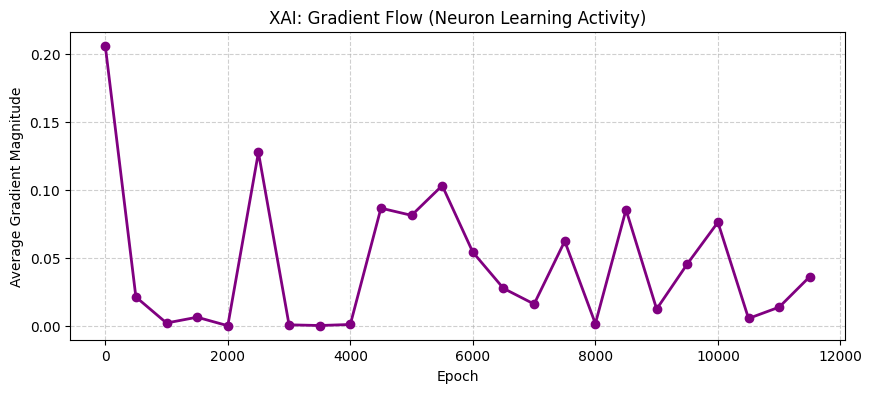

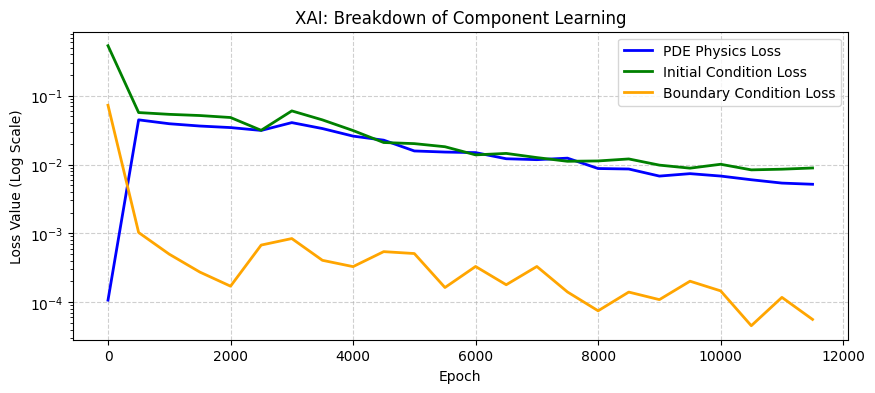

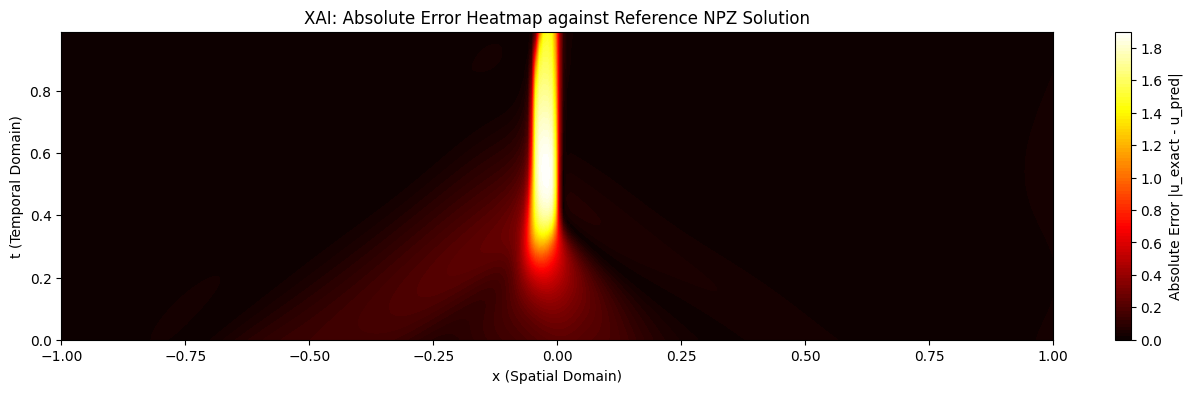

In [ ]:
# QUANTUM CIRCUIT DEFINITION
n_qubits = 4
n_layers = 1
dev = qp.device("default.qubit", wires=n_qubits)

@qp.qnode(dev, interface="torch", diff_method="backprop")
def qcircuit(inputs, weights):
    for i in range(n_layers):
        qp.AngleEmbedding(inputs, wires=range(n_qubits))
        for j in range(n_qubits):
            qp.RX(weights[(3*i)*(n_qubits)+j], wires=j)
        for j in range(n_qubits):
            qp.RZ(weights[(3*i + 1)*(n_qubits)+j], wires=j)
        for j in range(n_qubits):
            if j == 0:
                qp.CRX(weights[(3*i + 2)*(n_qubits)+j], wires=[n_qubits-j-1, 0])
            else:
                qp.CRX(weights[(3*i + 2)*(n_qubits)+j], wires=[n_qubits-j-1, n_qubits-j])

    return [qp.expval(qp.PauliZ(wires=i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_qubits*3*n_layers,)}

# QCPINN MODEL ARCHITECTURE
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, n_qubits),
            nn.Tanh()
        )
        self.qmap_layer = qp.qnn.TorchLayer(qcircuit, weight_shapes)
        self.post = nn.Sequential(
            nn.Linear(n_qubits, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        h = self.pre(inputs)
        q = self.qmap_layer(h)
        return self.post(q)

# PHYSICS LOSS FUNCTIONS
def pde_residual(x, t, model, nu=0.01):
    x.requires_grad = True
    t.requires_grad = True

    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u*u_x - (nu/np.pi)*u_xx
    return residual

def initial_condition(x):
    return -torch.sin(np.pi*x)

def boundary_condition(x, t):
    return torch.zeros_like(t)

# TRAINING DATA PREPARATION
x = torch.linspace(-1, 1, 50).view(-1, 1)
t = torch.linspace(0, 1, 50).view(-1, 1)
x_train, t_train = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='xy')
x_train = x_train.reshape(-1, 1)
t_train = t_train.reshape(-1, 1)

# INITIALIZATION & XAI TRACKERS
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.005)

num_epochs = 12000
l = []

# XAI Tracking Lists
grad_history = []
loss_pde_history = []
loss_ic_history = []
loss_bc_history = []
epoch_logs = []

# TRAINING LOOP
for epoch in range(num_epochs):
    model.train()

    # Initial Condition Loss
    u_pred = model(x, torch.zeros_like(x))
    u_true = initial_condition(x)
    loss_ic = torch.mean((u_pred - u_true)**2)

    # Boundary Condition Loss
    u_pred_left = model(torch.full_like(t, -1), t)
    u_pred_right = model(torch.full_like(t, 1), t)
    loss_bc = torch.mean((u_pred_left - boundary_condition(torch.full_like(t, -1), t))**2) + \
              torch.mean((u_pred_right - boundary_condition(torch.full_like(t, 1), t))**2)

    # PDE Residual Loss
    residual = pde_residual(x_train, t_train, model)
    loss_pde = torch.mean(residual**2)

    # Total Loss
    loss = loss_ic + loss_bc + loss_pde

    optimizer.zero_grad()
    loss.backward()


    # XAI GRADIENT EXTRACTION (Every 500 epochs)

    if epoch % 500 == 0:
        total_grad = 0.0
        param_count = 0
        for param in model.parameters():
            if param.grad is not None:
                total_grad += param.grad.abs().mean().item()
                param_count += 1

        avg_grad = total_grad / param_count if param_count > 0 else 0

        grad_history.append(avg_grad)
        loss_pde_history.append(loss_pde.item())
        loss_ic_history.append(loss_ic.item())
        loss_bc_history.append(loss_bc.item())
        epoch_logs.append(epoch)


    optimizer.step()
    l.append(loss.item())

    if epoch % 500 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Total Loss: {loss.item():.4f}')

# XAI DELIVERABLE VISUALIZATIONS

print("\nGenerating XAI Visualizations...")

# XAI Plot 1: Gradient Flow
plt.figure(figsize=(10, 4))
plt.plot(epoch_logs, grad_history, color='purple', linewidth=2, marker='o')
plt.title("XAI: Gradient Flow (Neuron Learning Activity)")
plt.xlabel("Epoch")
plt.ylabel("Average Gradient Magnitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# XAI Plot 2: Loss Components Breakdown
plt.figure(figsize=(10, 4))
plt.plot(epoch_logs, loss_pde_history, label='PDE Physics Loss', color='blue', linewidth=2)
plt.plot(epoch_logs, loss_ic_history, label='Initial Condition Loss', color='green', linewidth=2)
plt.plot(epoch_logs, loss_bc_history, label='Boundary Condition Loss', color='orange', linewidth=2)
plt.title("XAI: Breakdown of Component Learning")
plt.xlabel("Epoch")
plt.ylabel("Loss Value (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# XAI Plot 3: Absolute Error Heatmap
model.eval()
with torch.no_grad():
    # Format the reference NPZ data for the PyTorch model
    x_ref_flat = torch.tensor(x_ref.flatten(), dtype=torch.float32).view(-1, 1)
    t_ref_flat = torch.tensor(t_ref.flatten(), dtype=torch.float32).view(-1, 1)

    # Generate predictions across the entire reference grid
    u_pred_eval = model(x_ref_flat, t_ref_flat).numpy()

# Reshape back to the 2D grid shape (e.g., 256x100) to match 'exact'
u_pred_eval = u_pred_eval.reshape(exact.shape)
error_matrix = np.abs(exact - u_pred_eval)

plt.figure(figsize=(16, 4))
heatmap = plt.contourf(x_ref, t_ref, error_matrix, levels=100, cmap='hot')
plt.colorbar(heatmap, label='Absolute Error |u_exact - u_pred|')
plt.xlabel('x (Spatial Domain)')
plt.ylabel('t (Temporal Domain)')
plt.title('XAI: Absolute Error Heatmap against Reference NPZ Solution')
plt.show()